In [10]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
conn = sqlite3.connect("../results/studies/optimization_k.db")

# List tables (optional, to see what's inside)
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)
print(tables)

# Read a specific table
df_params = pd.read_sql("SELECT * FROM trial_params;", conn)
df_values = pd.read_sql("SELECT * FROM trial_values;", conn)

conn.close()

df_params = df_params[["trial_id", "param_name", "param_value"]]
print(df_values)

                         name
0                     studies
1                version_info
2            study_directions
3       study_user_attributes
4     study_system_attributes
5                      trials
6       trial_user_attributes
7     trial_system_attributes
8                trial_params
9                trial_values
10  trial_intermediate_values
11           trial_heartbeats
12            alembic_version
    trial_value_id  trial_id  objective      value value_type
0                1         1          0  18.934110     FINITE
1                2         2          0  46.909089     FINITE
2                3         3          0  44.426020     FINITE
3                4         4          0   8.084633     FINITE
4                5         5          0  44.360302     FINITE
5                6         6          0  13.548580     FINITE
6                7         7          0  29.726286     FINITE
7                8         8          0  45.916936     FINITE
8                9    

In [12]:
df_params_pivot = df_params.pivot(
    index="trial_id",
    columns="param_name",
    values="param_value"
).reset_index()

df_params_pivot.columns.name = None

df_params_pivot["mAP"] = df_values["value"] / 100
df_params_pivot.head()

,trial_id,k,mAP
0,1,7.390515,0.189341
1,2,1.317168,0.469091
2,3,3.290856,0.444260
3,4,10.349809,0.080846
4,5,1.113588,0.443603


In [13]:
df_sorted_p = df_params_pivot.sort_values(by="mAP", ascending=False).reset_index()
best_k = df_sorted_p.iloc[0]["k"]
df_sorted_p.head()

,index,trial_id,k,mAP
0,41,42,2.087023,0.512392
1,32,33,1.963003,0.511199
2,17,18,2.053114,0.510978
3,20,21,1.975615,0.510497
4,21,22,2.020676,0.509742


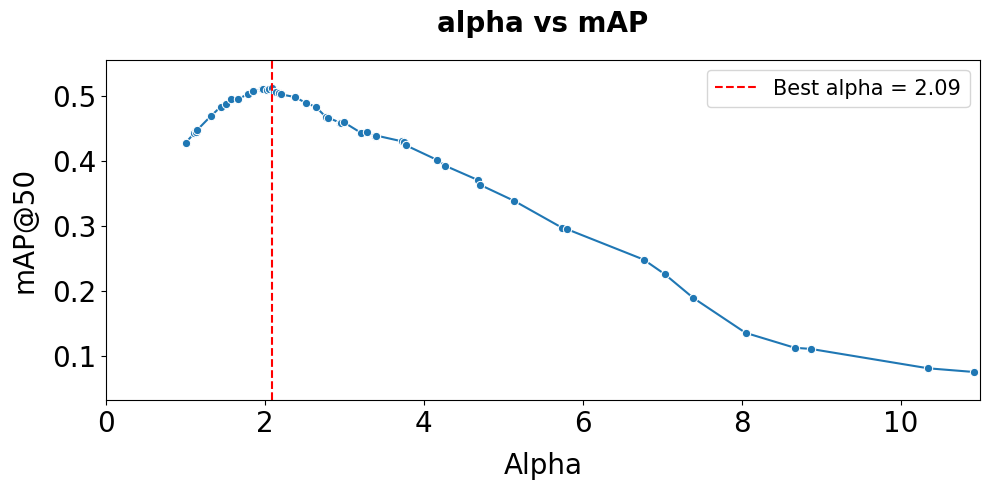

In [14]:
plt.figure(figsize=(10,5))
sns.lineplot(df_sorted_p, x="k", y="mAP", marker='o')
plt.xlim([0, 11])
plt.title("alpha vs mAP", fontsize=20, pad=20, fontweight='bold')
plt.ylabel("mAP@50", fontsize=20, labelpad=10)
plt.xlabel("Alpha", fontsize=20, labelpad=10)
plt.margins(y=0.1)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
plt.axvline(best_k, color="red", linestyle='--', label=f"Best alpha = {best_k:.2f}")
plt.legend(fontsize=15)

plt.tight_layout()
plt.show()


In [15]:
conn = sqlite3.connect("../results/studies/optuna_optimization.db")

# List tables (optional, to see what's inside)
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)
print(tables)

# Read a specific table
df_params = pd.read_sql("SELECT * FROM trial_params;", conn)
df_values = pd.read_sql("SELECT * FROM trial_values;", conn)

conn.close()

df_params = df_params[["trial_id", "param_name", "param_value"]]
print(df_values)
df_params_pivot = df_params.pivot(
    index="trial_id",
    columns="param_name",
    values="param_value"
).reset_index()

df_params_pivot.columns.name = None

df_params_pivot["mAP"] = df_values["value"] / 100
df_params_pivot.head()
df_sorted_p = df_params_pivot.sort_values(by="mAP", ascending=False).reset_index()
best_p = df_sorted_p.iloc[0]["p"]
df_sorted_p.head()

                         name
0                     studies
1                version_info
2            study_directions
3       study_user_attributes
4     study_system_attributes
5                      trials
6       trial_user_attributes
7     trial_system_attributes
8                trial_params
9                trial_values
10  trial_intermediate_values
11           trial_heartbeats
12            alembic_version
    trial_value_id  trial_id  objective      value value_type
0                1         2          0  24.480552     FINITE
1                2         3          0  17.217096     FINITE
2                3         4          0   6.943052     FINITE
3                4         5          0  14.655042     FINITE
4                5         6          0  56.066287     FINITE
..             ...       ...        ...        ...        ...
60              61        62          0  56.408978     FINITE
61              62        63          0  63.568272     FINITE
62              63    

,index,trial_id,close_morph_x,close_morph_y,k,min_cc_pixels,open_morph,p,mAP
0,22,23,26.0,55.0,2.294358,494.0,5.0,0.004387,0.647099
1,47,48,33.0,44.0,2.633764,547.0,4.0,0.005414,0.647017
2,35,36,30.0,29.0,3.104235,618.0,1.0,0.005866,0.643336
3,46,47,35.0,17.0,2.583178,589.0,5.0,0.008980,0.637855
4,51,52,33.0,42.0,2.466603,523.0,4.0,0.005337,0.637852


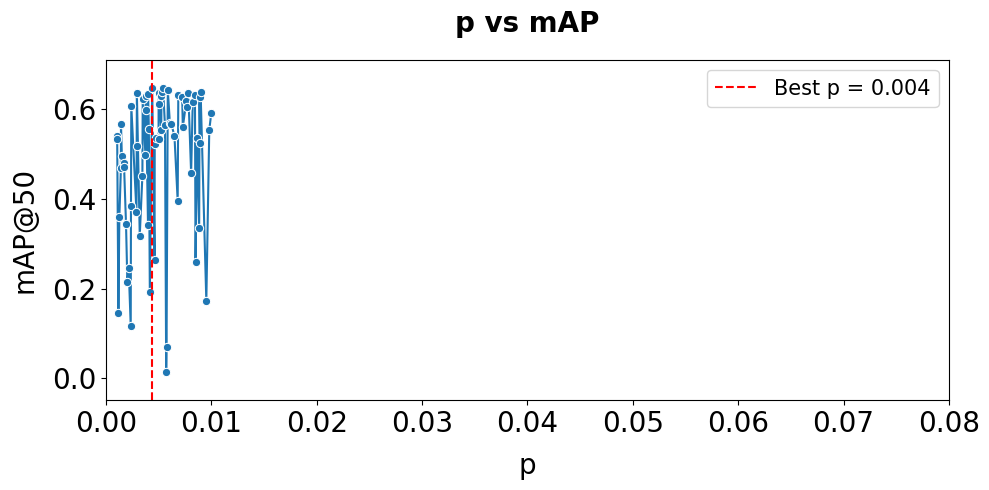

In [16]:
plt.figure(figsize=(10,5))
sns.lineplot(df_sorted_p, x="p", y="mAP", marker='o')
plt.xlim([0, 0.08])
plt.title("p vs mAP", fontsize=20, pad=20, fontweight='bold')
plt.ylabel("mAP@50", fontsize=20, labelpad=10)
plt.xlabel("p", fontsize=20, labelpad=10)
plt.margins(y=0.1)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
plt.axvline(best_p, color="red", linestyle='--', label=f"Best p = {best_p:.3f}")
plt.legend(fontsize=15)

plt.tight_layout()
plt.show()